In [66]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

from cftsdata.iec import IEC

from psiaudio.calibration import InterpCalibration
# Needed to load octave scale
import psiaudio.plot
from psiaudio.stim import apply_max_correction
from psiaudio import util

experiment_folder = Path('/volume1/data/physiology/pilot/20241120-IEC-ferret/20241120-134726 Jereme Stinkysquid right pilot inear_speaker_calibration_chirp')
sens_file = experiment_folder / 'chirp_sens.csv'
sens = pd.read_csv(sens_file, index_col=['hw_ao_chirp_level', 'frequency'])

In [42]:
# IEC is a subclass of psidata.Dataset that facilitates working with psiexperiment data
fh = IEC(experiment_folder)

# Load the microphone recordings to each individual presentation of the chirp
epochs = fh.get_epochs()

# Average across all presentations for each chirp level
epochs_mean = epochs.groupby('hw_ao_chirp_level').mean()

# Convert to PSD
epochs_mean_psd = util.psd_df(epochs_mean, fs=fh.hw_ai.fs)

# Load the calibration of the microphone that's embedded in the starship
mic_cal = fh.hw_ai.get_calibration()

# Convert PSD to SPL
epochs_mean_spl = mic_cal.get_db(epochs_mean_psd)

Text(0, 0.5, 'Phase (radians)')

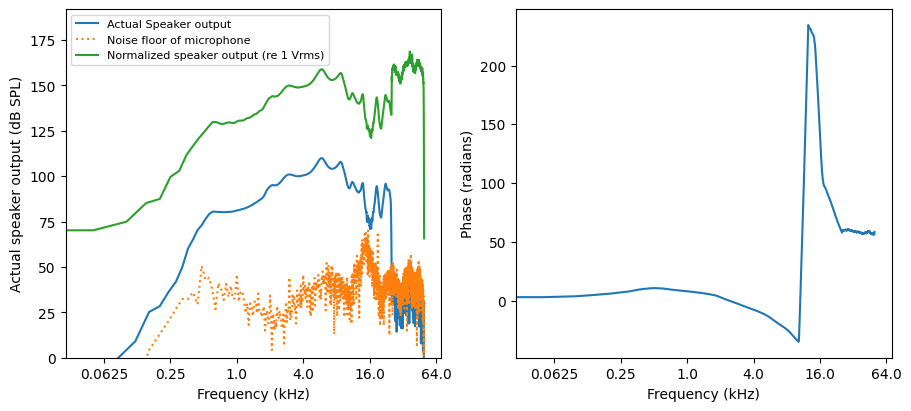

In [60]:
figure, axes = plt.subplots(1, 2, sharex=True, figsize=(9, 4), constrained_layout=True)

axes[0].plot(epochs_mean_spl.loc[-20], label='Actual Speaker output')
axes[0].plot(epochs_mean_spl.loc[-400], label='Noise floor of microphone', ls=':')

# This is normalized to 1 Vrms based on the actual chirp spectrum
axes[0].plot(sens.loc[-20, 'norm_spl'], label='Normalized speaker output (re 1 Vrms)')
axes[0].set_xscale('octave', octaves=2)
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Actual speaker output (dB SPL)')
axes[0].axis(ymin=0)
axes[0].legend(fontsize=8)

# This should be corrected for phase discrepancies in the embedded microphone
axes[1].plot(sens.loc[-20, 'phase'])
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Phase (radians)')

In [62]:
# Build a calibration object that will assist with calibrating stimuli
speaker_cal = InterpCalibration(
    sens.loc[-20].index.get_level_values('frequency'),
    sens.loc[-20, 'norm_spl'].values,
)

This code demonstrates how to generate a FIR filter that can be used to equalize stimuli within a given specified range (fl to fh Hz) at a given level in dB SPL. The `max_correction` factor specifies how much to actually equalize the stimulus in dB. If correction greater than the max correction is needed, that frequency will be corrected only up to `max_correction` (this avoids generating extremely large waveforms).

In [95]:
signal.firwin2?

Signature:
signal.firwin2(
    numtaps,
    freq,
    gain,
    nfreqs=None,
    window='hamming',
    nyq=None,
    antisymmetric=False,
    fs=None,
)
Docstring:
FIR filter design using the window method.

From the given frequencies `freq` and corresponding gains `gain`,
this function constructs an FIR filter with linear phase and
(approximately) the given frequency response.

Parameters
----------
numtaps : int
    The number of taps in the FIR filter.  `numtaps` must be less than
    `nfreqs`.
freq : array_like, 1-D
    The frequency sampling points. Typically 0.0 to 1.0 with 1.0 being
    Nyquist.  The Nyquist frequency is half `fs`.
    The values in `freq` must be nondecreasing. A value can be repeated
    once to implement a discontinuity. The first value in `freq` must
    be 0, and the last value must be ``fs/2``. Values 0 and ``fs/2`` must
    not be repeated.
gain : array_like
    The filter gains at the frequency sampling points. Certain
    constraints to gain values, dep

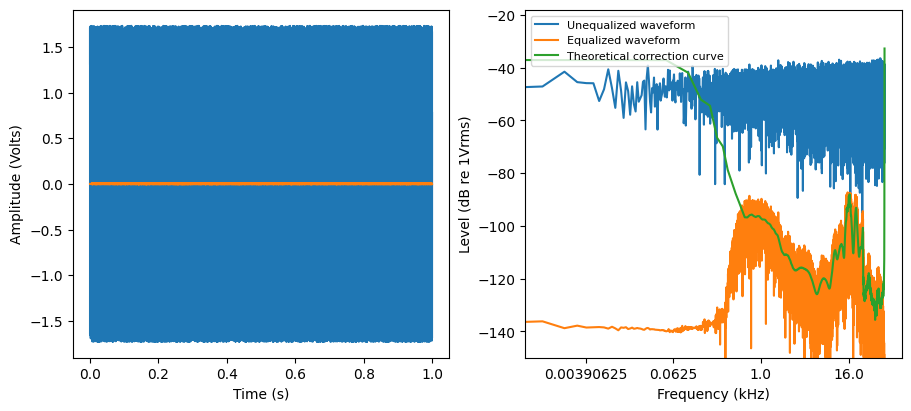

In [94]:
fl, fh = 500, 45000
level = 80
max_correction = 20
fs = 100e3
window = 'hann'
ntaps = 1001

freq = np.arange(fl, fh + 1)
sf = speaker_cal.get_sf(freq, level)

sf = apply_max_correction(sf, max_correction)
freq = np.concatenate(([0, fl / 1.1], freq, [fh * 1.1, fs / 2]))
sf = np.pad(sf, 2)

taps = signal.firwin2(ntaps, freq=freq, gain=sf, window=window, fs=fs)
zi = signal.lfilter_zi(taps, [1])

# The RMS value of noise drawn from a uniform distribution is
# amplitude/sqrt(3). By setting the low and high to sqrt(3) and
# multiplying by the scaling factors, we can ensure that the noise is
# initially generated with the desired RMS.
scale = np.sqrt(3)

rng = np.random.RandomState()
samples = int(fs)
waveform = rng.uniform(low=-scale, high=scale, size=samples)
eq_waveform, zi = signal.lfilter(taps, [1], waveform, zi=zi)

figure, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
t = np.arange(len(waveform)) / fs
axes[0].plot(t, waveform)
axes[0].plot(t, eq_waveform)

waveform_db = util.db(util.psd_df(waveform, fs))
eq_waveform_db = util.db(util.psd_df(eq_waveform, fs))
axes[1].plot(waveform_db, label='Unequalized waveform')
axes[1].plot(eq_waveform_db, label='Equalized waveform')
axes[1].set_xscale('octave', octaves=4)
axes[1].axis(ymin=-150)

# Verify that the correction factor matches the level
axes[1].plot(util.band_to_spectrum_level(80, len(waveform_db)) - sens.loc[-20, 'norm_spl'], label='Theoretical correction curve')

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (Volts)')
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Level (dB re 1Vrms)')
axes[1].legend(fontsize=8)

33.01021309861201